# **Calculating VaR using Historical Simulation**

The Historical Simulation method is a non-parametric approach to estimating Value at Risk (VaR) that relies directly on historical return data rather than assuming any specific statistical distribution. Under this method, past portfolio returns are reordered from worst to best, and the VaR is determined by selecting the appropriate percentile corresponding to the chosen confidence level.

This approach implicitly assumes that future risk patterns will resemble historical market behavior. While it is intuitive and easy to implement, Historical VaR may fail to capture tail risks or extreme market events that are not present in the historical dataset, and it does not explicitly account for changing market dynamics. Despite these limitations, it remains a widely used baseline risk measure in portfolio risk management.

**Formula:
VaR= -Return at the (100-confidence level) percentile**


In [1]:
#Importing Required Libraries
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

years=15

end_date= dt.datetime.now()
start_date= end_date - dt.timedelta(days=365*years)

tickers= ['ICICIBANK.NS','HDFCBANK.NS','KOTAKBANK.NS','AXISBANK.NS','^NSEI']

In [ ]:
adj_close_df= pd.DataFrame()
for ticker in tickers:
  data=yf.download(ticker,start=start_date,end=end_date)
  adj_close_df[ticker]=data['Close']

log_retruns=np.log(adj_close_df/adj_close_df.shift(1))
log_retruns.dropna()

In [3]:
portfolio_value=1000000
weights= np.array([1/len(tickers)]*len(tickers))

historical_retruns= (log_retruns*weights).sum(axis=1)

In [4]:
days = 5
range_returns= historical_retruns.rolling(window=days).sum()
range_returns= range_returns.dropna()

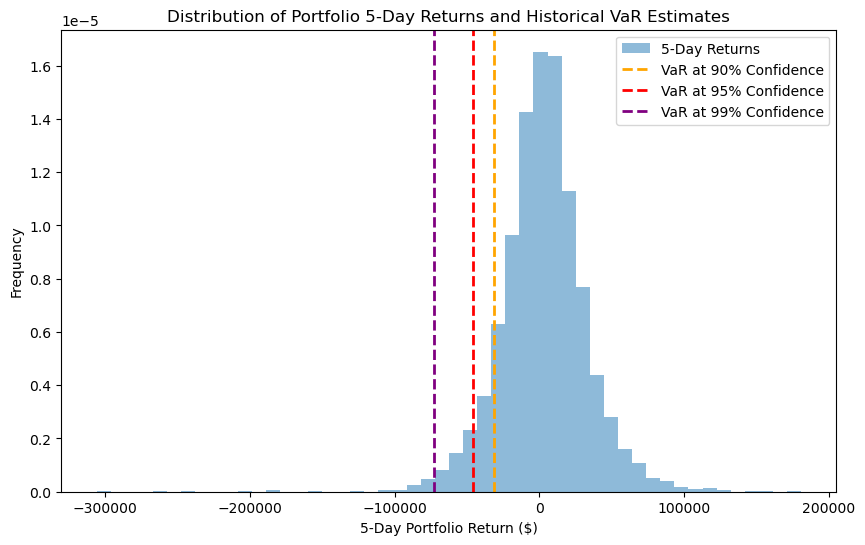

In [5]:
# Convert returns to dollar values
range_returns_dollar = range_returns * portfolio_value

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(range_returns_dollar, bins=50, density=True, alpha=0.5, label=f'{days}-Day Returns')

# Confidence levels and colors
confidence_levels = [0.90, 0.95, 0.99]
colors = {0.90: 'orange', 0.95: 'red', 0.99: 'purple'}

# Plot VaR lines
for cl in confidence_levels:
    VaR = -np.percentile(range_returns, (1 - cl) * 100) * portfolio_value
    plt.axvline(x=-VaR, color=colors[cl], linestyle='--', linewidth=2, label=f'VaR at {int(cl * 100)}% Confidence')

plt.xlabel(f'{days}-Day Portfolio Return ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}-Day Returns and Historical VaR Estimates')
plt.legend()
plt.show()